In [1]:
# Load validation dataset
import pandas as pd

df = pd.read_csv("./data/datasets/combined_test.csv")
human_texts = df.loc[df["generated"] == 0, "text"].tolist()
ai_texts = df.loc[df["generated"] == 1, "text"].tolist()

In [2]:
from local_utilities.dataset import tokenize_text

tokenized_human = []
tokenized_ai = []

for text in human_texts:
    tokenized_human.extend(tokenize_text(text))

for text in ai_texts:
    tokenized_ai.extend(tokenize_text(text))

[nltk_data] Downloading package punkt_tab to /home/tobias/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
/home/tobias/.pyenv/versions/genai/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print(len(tokenized_human))
print(len(tokenized_ai))

108177
104535


In [4]:
# Get human results
from local_utilities import evaluate
from local_utilities.gpu import get_gpu
import torch
from tqdm import tqdm

from transformers import logging
logging.disable_progress_bar()

device = get_gpu()

human_ffnn_results = []
human_distilbert_results = []
human_roberta_results = []
human_svm_results = []
steps = 396
human_len = len(tokenized_human)

for i in tqdm(range(0, human_len, steps)):
    # Set max i
    max_i = i + steps
    if max_i > human_len:
        max_i = human_len

    _, ffnn, distilbert, roberta, svm, _ = \
        evaluate(tokenized_human[i:max_i], device=device)

    human_ffnn_results.extend(ffnn)
    human_distilbert_results.extend(distilbert)
    human_roberta_results.extend(roberta)
    human_svm_results.extend(svm)

100%|██████████| 274/274 [09:16<00:00,  2.03s/it]


In [5]:
# Get AI
ai_ffnn_results = []
ai_distilbert_results = []
ai_roberta_results = []
ai_svm_results = []
ai_len = len(tokenized_ai)
steps = 396

for i in tqdm(range(0, ai_len, steps)):
    # Set max i
    max_i = i + steps
    if max_i > ai_len:
        max_i = ai_len

    _, ffnn, distilbert, roberta, svm, _ = \
        evaluate(tokenized_ai[i:max_i], device=device)

    ai_ffnn_results.extend(ffnn)
    ai_distilbert_results.extend(distilbert)
    ai_roberta_results.extend(roberta)
    ai_svm_results.extend(svm)

100%|██████████| 264/264 [08:03<00:00,  1.83s/it]


In [6]:
AI_SCORE_CUTOFF = 0.5

In [7]:
x_svm = []
x_ffnn = []
x_distilbert = []
x_roberta = []
y = []

In [8]:
human_results_all = []
human_results_ffnn = []
human_results_distilbert = []
human_results_roberta = []
human_results_svm = []

for i in tqdm(range(len(human_ffnn_results))):
    human_ffnn = float(human_ffnn_results[i][0])
    ai_ffnn = float(human_ffnn_results[i][1])
    human_distilbert = float(human_distilbert_results[i][0])
    ai_distilbert = float(human_distilbert_results[i][1])
    human_roberta = float(human_roberta_results[i][0])
    ai_roberta = float(human_roberta_results[i][1])
    human_svm = float(human_svm_results[i][0])
    ai_svm = float(human_svm_results[i][1])
    
    x_svm.append(ai_svm)
    x_ffnn.append(ai_ffnn)
    x_distilbert.append(ai_distilbert)
    x_roberta.append(ai_roberta)
    y.append(0)

    human_score = (human_distilbert + human_roberta + human_ffnn + human_svm) / 4.0
    ai_score = (ai_distilbert + ai_roberta + ai_ffnn +  ai_svm) / 4.0

    if ai_ffnn >= AI_SCORE_CUTOFF:
        human_results_ffnn.append(1)
    else:
        human_results_ffnn.append(0)

    if ai_distilbert >= AI_SCORE_CUTOFF:
        human_results_distilbert.append(1)
    else:
        human_results_distilbert.append(0)

    if ai_roberta >= AI_SCORE_CUTOFF:
        human_results_roberta.append(1)
    else:
        human_results_roberta.append(0)

    if ai_svm >= AI_SCORE_CUTOFF:
        human_results_svm.append(1)
    else:
        human_results_svm.append(0)

    if ai_score >= AI_SCORE_CUTOFF:
        human_results_all.append(1)
    else:
        human_results_all.append(0)

100%|██████████| 105023/105023 [00:02<00:00, 36632.29it/s]


In [9]:
ai_results_all = []
ai_results_ffnn = []
ai_results_distilbert = []
ai_results_roberta = []
ai_results_svm = []

ai_results_probas = []

for i in tqdm(range(len(ai_ffnn_results))):
    human_ffnn = float(ai_ffnn_results[i][0])
    ai_ffnn = float(ai_ffnn_results[i][1])
    human_distilbert = float(ai_distilbert_results[i][0])
    ai_distilbert = float(ai_distilbert_results[i][1])
    human_roberta = float(ai_roberta_results[i][0])
    ai_roberta = float(ai_roberta_results[i][1])
    human_svm = float(ai_svm_results[i][0])
    ai_svm = float(ai_svm_results[i][1])
    
    x_svm.append(ai_svm)
    x_ffnn.append(ai_ffnn)
    x_distilbert.append(ai_distilbert)
    x_roberta.append(ai_roberta)
    y.append(1)

    human_score = (human_distilbert + human_roberta + human_ffnn + human_svm) / 4.0
    ai_score = (ai_distilbert + ai_roberta + ai_ffnn + ai_svm) / 4.0


    if ai_ffnn >= AI_SCORE_CUTOFF:
        ai_results_ffnn.append(1)
    else:
        ai_results_ffnn.append(0)

    if ai_distilbert >= AI_SCORE_CUTOFF:
        ai_results_distilbert.append(1)
    else:
        ai_results_distilbert.append(0)

    if ai_roberta >= AI_SCORE_CUTOFF:
        ai_results_roberta.append(1)
    else:
        ai_results_roberta.append(0)

    if ai_svm >= AI_SCORE_CUTOFF:
        ai_results_svm.append(1)
    else:
        ai_results_svm.append(0)

    if ai_score >= AI_SCORE_CUTOFF:
        ai_results_all.append(1)
    else:
        ai_results_all.append(0)

100%|██████████| 98635/98635 [00:02<00:00, 36948.51it/s]


In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import *

def compute_scores(human_results, ai_results, filename):
    # Compute values
    len_human = float(len(human_results))
    human_as_human = float(human_results.count(0))
    human_as_ai = float(human_results.count(1))

    len_ai = float(len(ai_results))
    ai_as_human = float(ai_results.count(0))
    ai_as_ai = float(ai_results.count(1))

    # Confusion matrix
    cm = np.array([
        [human_as_human, human_as_ai],
        [ai_as_human, ai_as_ai],
    ])

    cm_p = cm / cm.sum(axis=1, keepdims=True) * 100

    display = ConfusionMatrixDisplay(
        confusion_matrix = cm_p,
        display_labels = ["Human", "AI"]
    )

    display.plot(cmap="Blues", values_format=".2f")
    for text in display.text_.ravel():
        text.set_fontsize(20)
        
    plt.savefig(f"./data/figures/{filename}.pdf")
    plt.show()

    # Scores
    TN, FP, FN, TP = cm.ravel()
    y_true = [0] * len(human_results) + [1] * len(ai_results)
    y_pred = human_results + ai_results
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    specificity = TN / (TN + FP)
    
    print(f"{TN:,.0f} & {FP:,.0f} & {FN:,.0f} & {TP:,.0f} & {accuracy:.4f} & {precision:.4f}"
          f" & {recall:.4f} & {specificity:.4f} \\\\")

===== FFNN =====


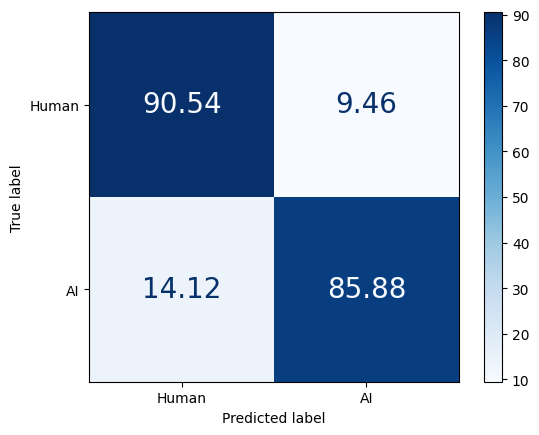

95,088 & 9,935 & 13,931 & 84,704 & 0.8828 & 0.8950 & 0.8588 & 0.9054 \\
===== SVM =====


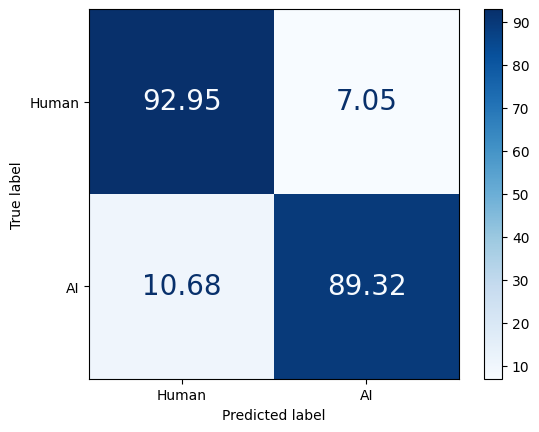

97,619 & 7,404 & 10,539 & 88,096 & 0.9119 & 0.9225 & 0.8932 & 0.9295 \\
===== RoBERTa =====


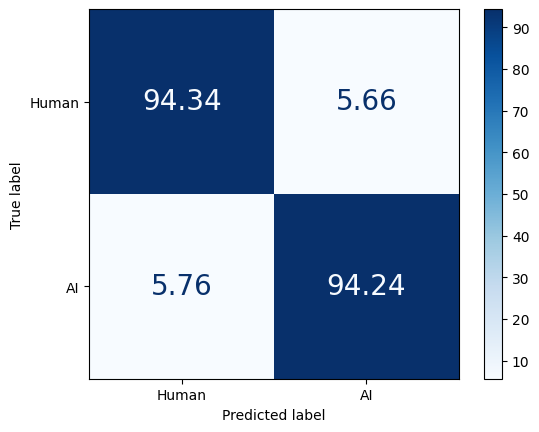

99,083 & 5,940 & 5,683 & 92,952 & 0.9429 & 0.9399 & 0.9424 & 0.9434 \\
===== DistilBERT =====


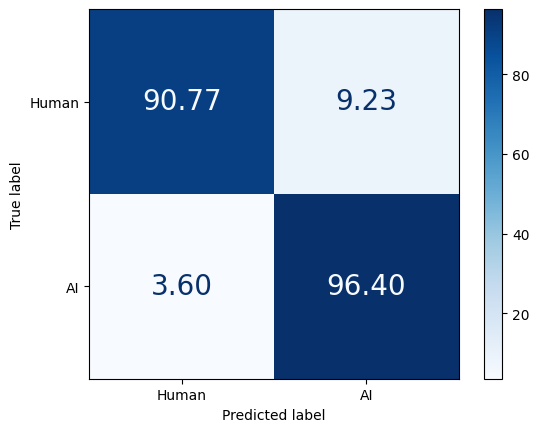

95,332 & 9,691 & 3,551 & 95,084 & 0.9350 & 0.9075 & 0.9640 & 0.9077 \\


In [11]:
print("===== FFNN =====")
compute_scores(human_results_ffnn, ai_results_ffnn, "ffnn")

print("===== SVM =====")
compute_scores(human_results_svm, ai_results_svm, "svm")

print("===== RoBERTa =====")
compute_scores(human_results_roberta, ai_results_roberta, "roberta")

print("===== DistilBERT =====")
compute_scores(human_results_distilbert, ai_results_distilbert, "distilbert")

In [12]:
# Store results
import pandas as pd

df = pd.DataFrame({
    "ai_svm": x_svm,
    "ai_ffnn": x_ffnn,
    "ai_distilbert": x_distilbert,
    "ai_roberta": x_roberta,
    "y": y
})
df.to_csv("./data/datasets/combined_results.csv", index=False)